In [1]:
import networkx as nx
import numpy as np
from data import GraphDataset
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

data = GraphDataset()

/home/borkeren/Desktop/AML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/borkeren/Desktop/AML/.venv/lib/python3.12/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/datasets/graphs-datasets/MUTAG/resolve/d0d278691a40f1d671294d5f3690a18acf6e0270/MUTAG.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since graphs-datasets/MUTAG couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/borkeren/.cache/huggingface/datasets/gra

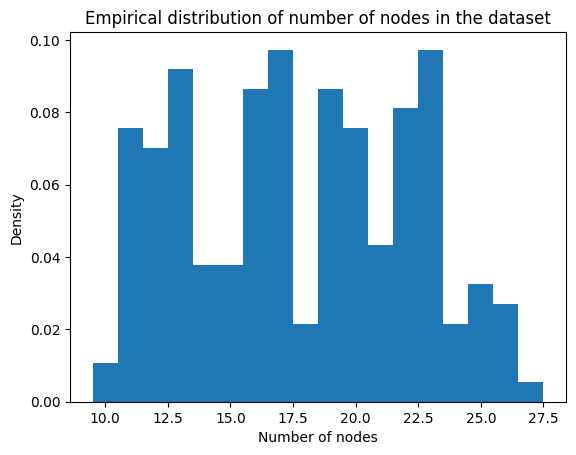

In [2]:
# histogram over data.num_nodes
import matplotlib.pyplot as plt
plt.hist(data.num_nodes, bins=np.arange(min(data.num_nodes), max(data.num_nodes) + 1) - 0.5, density=True)
plt.xlabel("Number of nodes")
plt.ylabel("Density")
plt.title("Empirical distribution of number of nodes in the dataset")
plt.show()

# Sample 1000 baseline graphs

In [3]:
baseline_graphs = [data.sample_graph() for _ in range(1000)]

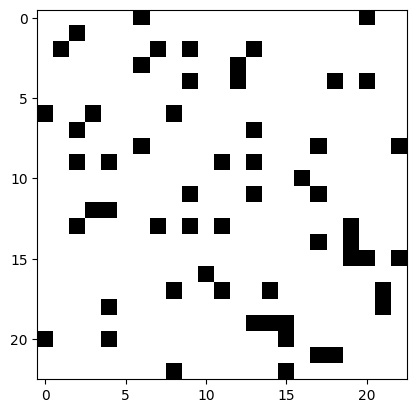

In [4]:
from matplotlib import pyplot as plt
plt.imshow(nx.to_numpy_array(baseline_graphs[3]), cmap="Greys", vmin=0, vmax=1)
plt.show()

## Novelty & Unique

In [5]:
novel_generated_graphs = []
unique_hashes = set()

novel_and_unique = []

for sample in baseline_graphs:
    sample_hash = weisfeiler_lehman_graph_hash(sample, iterations=20)
    if sample_hash in data.hashes:
        print("Found a duplicate graph in the baseline samples!")
    else:
        novel_generated_graphs.append(sample)
        if sample_hash not in unique_hashes:
            novel_and_unique.append(sample)
    unique_hashes.add(sample_hash)

print(f"Number of novel generated graphs: {len(novel_generated_graphs)}")
print(f"Number of unique generated graphs: {len(unique_hashes)}")
print(f"Number of novel and unique graphs in baseline samples: {len(novel_and_unique)}")


/home/borkeren/Desktop/AML/.venv/lib/python3.12/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


Number of novel generated graphs: 1000
Number of unique generated graphs: 1000
Number of novel and unique graphs in baseline samples: 1000


# Graph Statistics

Node Degree  

Node Centrality  

Eigenvector Centrality    


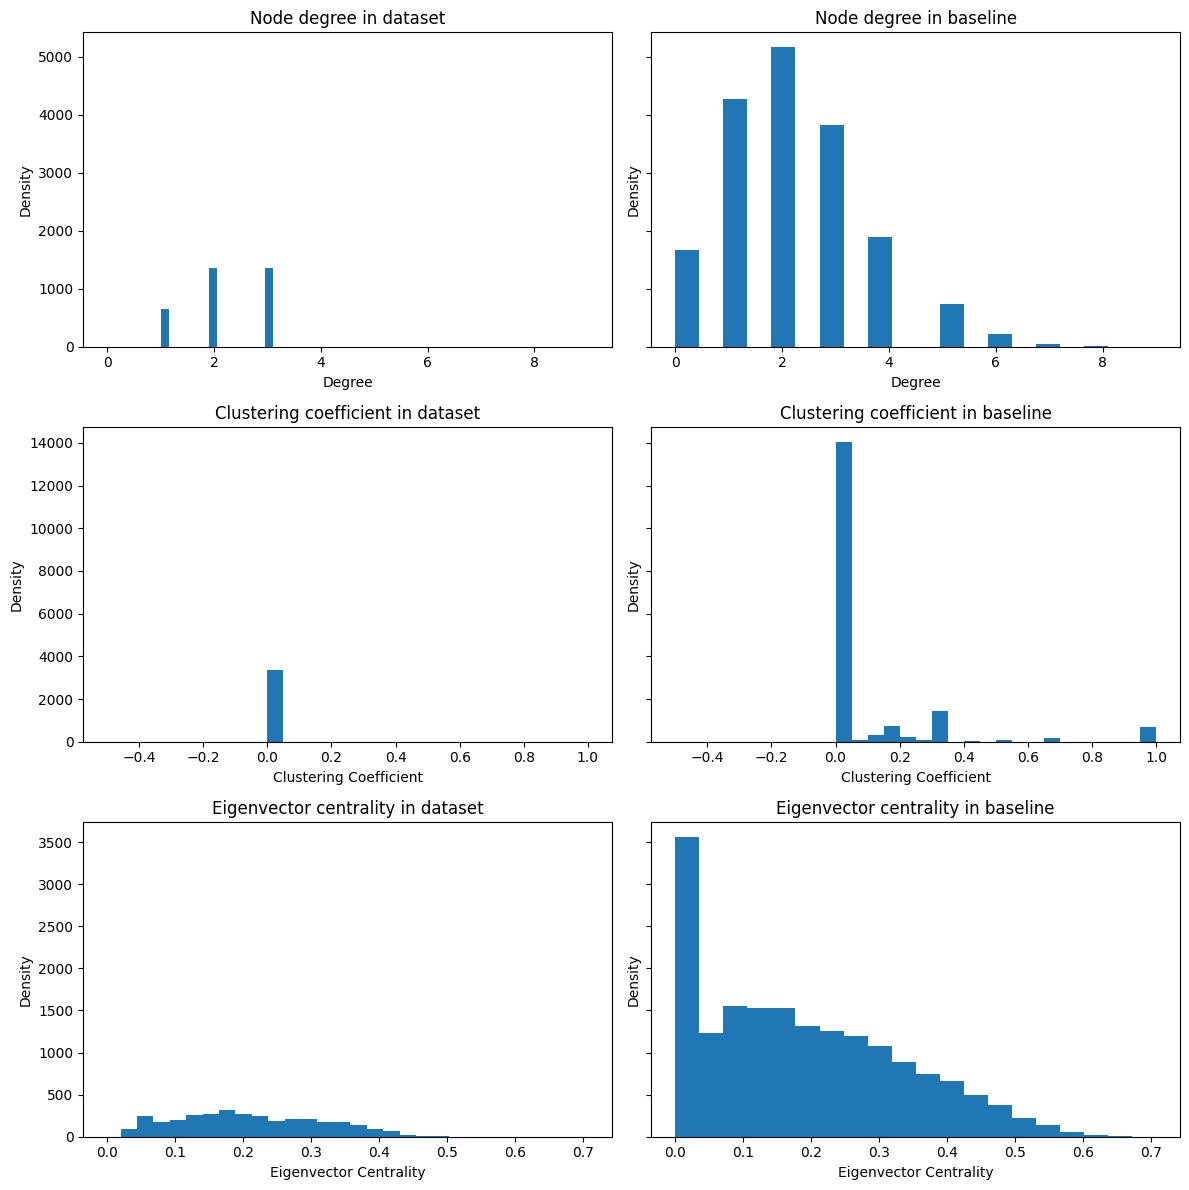

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a 3x2 grid (increased height to accommodate the third row)
fig, axs = plt.subplots(3, 2, figsize=(12, 12), sharex='row', sharey='row')

def plot_distribution(ax, graphs, metric, title, xlabel):
    values = []
    for graph in graphs:
        if metric == 'degree':
            values.extend(dict(graph.degree()).values())
        elif metric == 'clustering':
            values.extend(list(nx.clustering(graph).values()))
        elif metric == 'eigenvector':
            # max_iter is increased to 1000 to prevent convergence errors on complex graphs
            values.extend(list(nx.eigenvector_centrality(graph, max_iter=10000).values()))
            
    ax.hist(values, bins=20, density=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

# 1. Degree Distributions (Top Row)
plot_distribution(axs[0, 0], data.networkx_graphs, 'degree', 
                  "Node degree in dataset", "Degree")
plot_distribution(axs[0, 1], baseline_graphs, 'degree', 
                  "Node degree in baseline", "Degree")

# 2. Clustering Coefficient Distributions (Middle Row)
plot_distribution(axs[1, 0], data.networkx_graphs, 'clustering', 
                  "Clustering coefficient in dataset", "Clustering Coefficient")
plot_distribution(axs[1, 1], baseline_graphs, 'clustering', 
                  "Clustering coefficient in baseline", "Clustering Coefficient")

# 3. Eigenvector Centrality Distributions (Bottom Row)
plot_distribution(axs[2, 0], data.networkx_graphs, 'eigenvector', 
                  "Eigenvector centrality in dataset", "Eigenvector Centrality")
plot_distribution(axs[2, 1], baseline_graphs, 'eigenvector', 
                  "Eigenvector centrality in baseline", "Eigenvector Centrality")

plt.tight_layout()
plt.show()